Dataset shape: (10127, 17)
Features: (10127, 16)
Target distribution:
Attrition_Flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64
Train shape: (7088, 16)
Test shape: (3039, 16)
ANN pipeline ready.
ANN training completed.
Iterations used: 59
Final loss: 0.03237313522209436
              precision    recall  f1-score   support

    No Churn       0.95      0.98      0.96      2551
       Churn       0.86      0.75      0.80       488

    accuracy                           0.94      3039
   macro avg       0.90      0.86      0.88      3039
weighted avg       0.94      0.94      0.94      3039



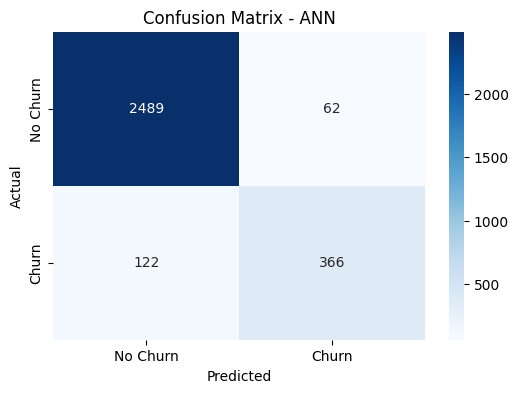

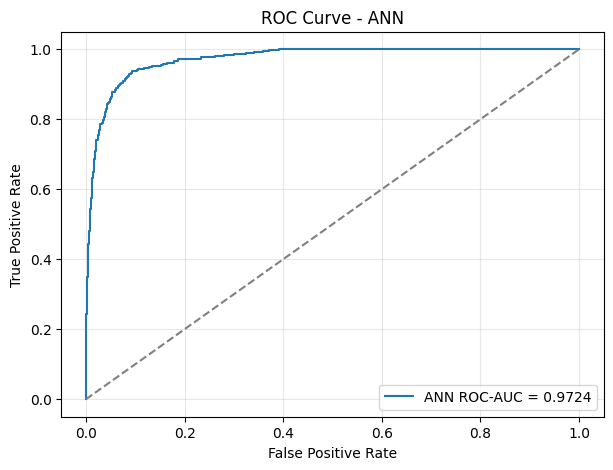

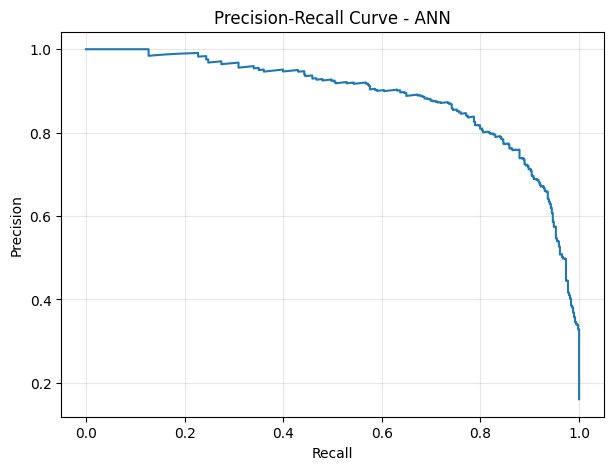

Best threshold by F1:
Threshold    0.240000
Precision    0.788868
Recall       0.842213
F1-Score     0.814668
Name: 23, dtype: float64


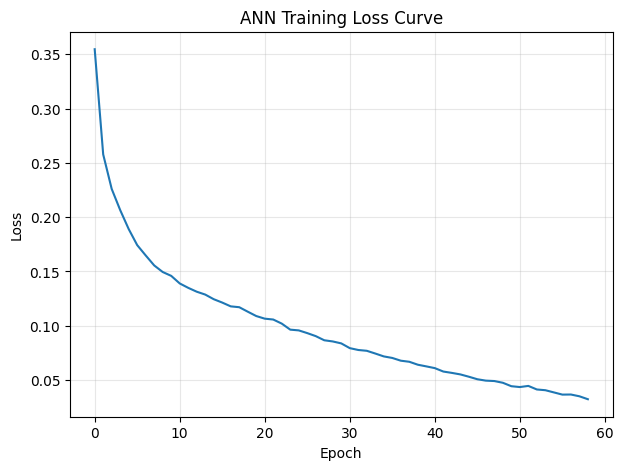

In [1]:
# ============================================================
# ANN ONLY MODEL - BANK CHURN PREDICTION
# ============================================================

import os
import json
import cloudpickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

# ============================================================
# 1. LOAD DATA
# ============================================================

DATA_PATH = "BankChurners.csv"

df = pd.read_csv(DATA_PATH)

df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

drop_cols = [
    "CLIENTNUM",
    "Credit_Limit",
    "Dependent_count",
    "Avg_Open_To_Buy",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

X = df.drop("Attrition_Flag", axis=1)
y = df["Attrition_Flag"]

print("Dataset shape:", df.shape)
print("Features:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

# ============================================================
# 2. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=43,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ============================================================
# 3. FEATURE GROUPS
# ============================================================

num_features = [
    "Customer_Age",
    "Months_on_book",
    "Total_Relationship_Count",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Total_Revolving_Bal",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]

cat_features = [
    "Gender",
    "Education_Level",
    "Marital_Status",
    "Income_Category",
    "Card_Category",
]

# ============================================================
# 4. PREPROCESSOR
# ANN NEEDS SCALING + ONE-HOT ENCODING
# ============================================================

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        num_features
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore", drop="first"),
        cat_features
    )
])

# ============================================================
# 5. ANN MODEL
# ============================================================

ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

ann_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("ann", ann_model)
])

print("ANN pipeline ready.")

# ============================================================
# 6. TRAIN ANN
# ============================================================

ann_pipeline.fit(X_train, y_train)

print("ANN training completed.")
print("Iterations used:", ann_pipeline.named_steps["ann"].n_iter_)
print("Final loss:", ann_pipeline.named_steps["ann"].loss_)

# ============================================================
# 7. EVALUATE ANN AT DEFAULT THRESHOLD 0.50
# ============================================================

THRESHOLD = 0.50

y_prob = ann_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

metrics = {
    "Model": "ANN (MLP)",
    "Threshold": THRESHOLD,
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
    "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
    "F1-Score": round(f1_score(y_test, y_pred, zero_division=0), 4),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
}

pd.DataFrame([metrics])

# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ANN")
plt.show()

# ============================================================
# 10. ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ANN ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 11. PRECISION-RECALL CURVE
# ============================================================

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - ANN")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 12. FIND BEST THRESHOLD BY F1
# ============================================================

thresholds = np.arange(0.01, 0.99, 0.01)

threshold_results = []

for t in thresholds:
    pred_t = (y_prob >= t).astype(int)

    threshold_results.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_test, pred_t, zero_division=0),
        "Recall": recall_score(y_test, pred_t, zero_division=0),
        "F1-Score": f1_score(y_test, pred_t, zero_division=0),
    })

df_thresholds = pd.DataFrame(threshold_results)
best_threshold_row = df_thresholds.sort_values("F1-Score", ascending=False).iloc[0]

print("Best threshold by F1:")
print(best_threshold_row)

df_thresholds.head()

# ============================================================
# 13. EVALUATE USING BEST THRESHOLD
# ============================================================

BEST_THRESHOLD = float(best_threshold_row["Threshold"])

y_pred_best = (y_prob >= BEST_THRESHOLD).astype(int)

best_metrics = {
    "Model": "ANN (MLP)",
    "Threshold": BEST_THRESHOLD,
    "Accuracy": round(accuracy_score(y_test, y_pred_best), 4),
    "Precision": round(precision_score(y_test, y_pred_best, zero_division=0), 4),
    "Recall": round(recall_score(y_test, y_pred_best, zero_division=0), 4),
    "F1-Score": round(f1_score(y_test, y_pred_best, zero_division=0), 4),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
}

pd.DataFrame([metrics, best_metrics])

# ============================================================
# 14. ANN LOSS CURVE
# ============================================================

loss_curve = ann_pipeline.named_steps["ann"].loss_curve_

plt.figure(figsize=(7, 5))
plt.plot(loss_curve)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training Loss Curve")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 15. TEST SINGLE CUSTOMER PREDICTION
# ============================================================

sample_customer = pd.DataFrame([{
    "Customer_Age": 45,
    "Gender": "M",
    "Education_Level": "Graduate",
    "Marital_Status": "Married",
    "Income_Category": "$60K - $80K",
    "Card_Category": "Blue",
    "Months_on_book": 36,
    "Total_Relationship_Count": 4,
    "Months_Inactive_12_mon": 2,
    "Contacts_Count_12_mon": 3,
    "Total_Revolving_Bal": 1000,
    "Total_Amt_Chng_Q4_Q1": 0.8,
    "Total_Trans_Amt": 400
}])

#model_path = os.path.join(MODEL_DIR, "ann_mlp.pkl")

# with open(model_path, "wb") as f:
#     cloudpickle.dump(ann_pipeline, f)

# print(f"Saved ANN model to: {model_path}")

